<a href="https://colab.research.google.com/github/SakshamStha47/Bus_Stop_Accessibility_Analysis-Old_West_Side/blob/main/Bus_Stop_Accessibility_Analysis_Old_West_Side.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **BUS STOP ACCESSIBILITY ANALYSIS OF OLD WEST SIDE, ANN ARBOR, MICHIGAN, USA**

---



In this notebook, we will plot the bus stops within Old West Side, Ann Arbor, Michigan, USA and then access the accessibility of bus stops using buffer zones.
We will follow the following steps to reach our final position:
1.   Load the GDFs of the areas of interest (Old West Side and Ann Arbor)
2.   Load the road network within Old West Side
3.   Load the positions of bus stops within the neighborhood.
4.   Create an accessibility buffer zone around the bus stops.
5.   Deduct spots where the buffers zones don't overlap to obtain blind spots.



In [3]:
# Loading dependencies...
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd

## Obtain GeoDataFrames of the Areas of Interest:

In [7]:
ann_arbor = ox.geocode_to_gdf("Ann Arbor, Michigan, USA")
old_west_side = ox.geocode_to_gdf("Old West Side, Ann Arbor, Michigan, USA")

## Let's Visualize the Position of Old West Side on Ann Arbor

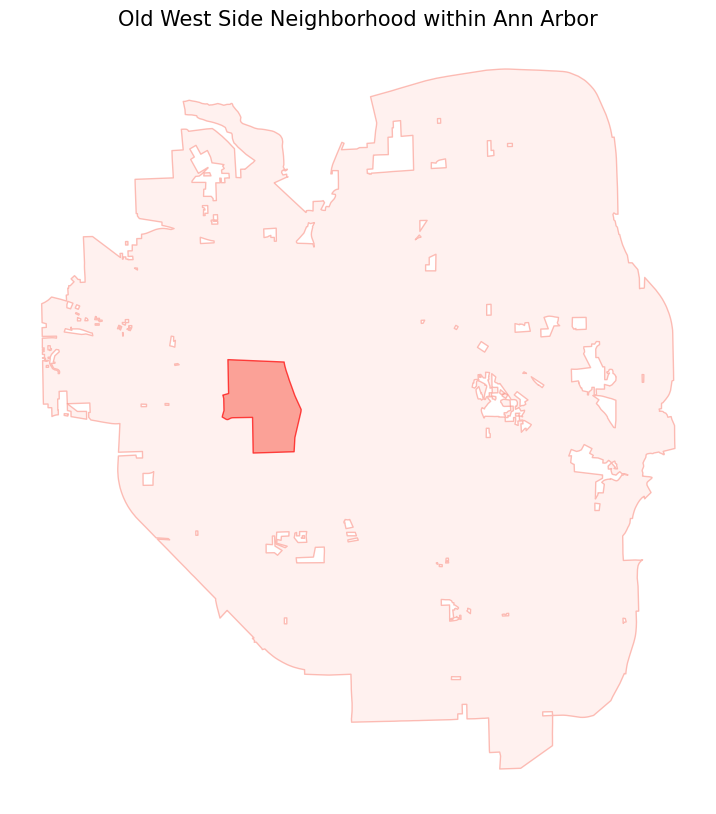

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

ann_arbor.plot(ax = ax, color = "mistyrose", edgecolor = "salmon", alpha = 0.5)
old_west_side.plot(ax = ax, color = "salmon", edgecolor = "red", alpha = 0.7)

ax.set_title("Old West Side Neighborhood within Ann Arbor", fontsize=15)
ax.axis("off")
plt.show()

### Obtaining Bus Stop data
We extract the bus stops within Old West Side using the `{"highway": "bus_stop"}` tag. The tags are obtained from OSM wiki.

https://wiki.openstreetmap.org/wiki/Tags

Then the points are plotted out on top of Old West Side

In [49]:
neighborhood_poly = old_west_side.geometry.iloc[0]

tags = {"highway": "bus_stop"}

bus_stops = ox.features_from_polygon(neighborhood_poly, tags)

bus_stops.head()

geometry bench  bin  bus  \
element id                                                       
node    3908834356  POINT (-83.75802 42.27799)    no   no  yes   
        3908834957  POINT (-83.75579 42.27845)    no   no  yes   
        3908834958  POINT (-83.75964 42.27781)    no  NaN  yes   
        3908834959  POINT (-83.75753 42.27388)   NaN  NaN  yes   
        3908834960  POINT (-83.75482 42.27392)    no  yes  yes   

                   check_date:shelter   highway  lit  \
element id                                             
node    3908834356         2023-07-25  bus_stop   no   
        3908834957         2023-07-25  bus_stop   no   
        3908834958                NaN  bus_stop   no   
        3908834959                NaN  bus_stop  NaN   
        3908834960                NaN  bus_stop   no   

                                          name network network:wikidata note  \
element id                                                                     
node    3908834356           Liberty + Seventh   AAATA         Q4766233  #28   
        3908834957             Liberty + Fifth   AAATA         Q4766233  #28   
        3908834958           Liberty + Seventh   AAATA         Q4766233  NaN   
        3908834959   S - Madison west of Sixth   AAATA         Q4766233  897   
        3908834960  S - Madison west of Fourth     NaN              NaN  898   

                   operator public_transport  ref shelter tactile_paving  \
element id                                                                 
node    3908834356    AAATA         platform  747      no             no   
        3908834957    AAATA         platform  748      no             no   
        3908834958    AAATA         platform  753      no            NaN   
        3908834959      NaN         platform   15     NaN            NaN   
        3908834960      NaN         platform   15      no            yes   

                   passenger_information_display  
element id                                        
node    3908834356                           NaN  
        3908834957                            no  
        3908834958                            no  
        3908834959                           NaN  
        3908834960                           NaN

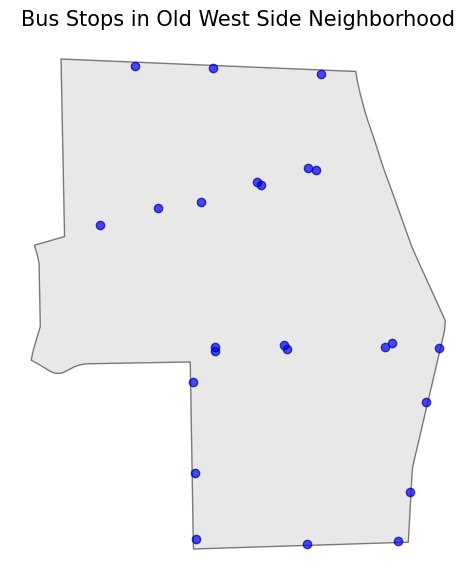

In [50]:
fig, ax = plt.subplots(figsize=(7, 7))

old_west_side.plot(ax = ax, color = "lightgray", edgecolor = "black", alpha = 0.5)
bus_stops.plot(ax = ax, color = "blue", edgecolor = "darkblue", alpha = 0.7)

ax.set_title("Bus Stops in Old West Side Neighborhood", fontsize=15)
ax.axis("off")
plt.show()

The below loaded graph is in geographic coordinate system, which uses latitude and longitude coordinates. Distances in this system are measured in degrees, which can lead to inaccuracies when performing spatial calculations like buffering. Thus we convert the graph into a projected graph using the `.to_crs` attribute that uses a much more accurate local, meter-based projected coordinate system.

After all elements are in crs, they can be plotted ensuring proper alignment.

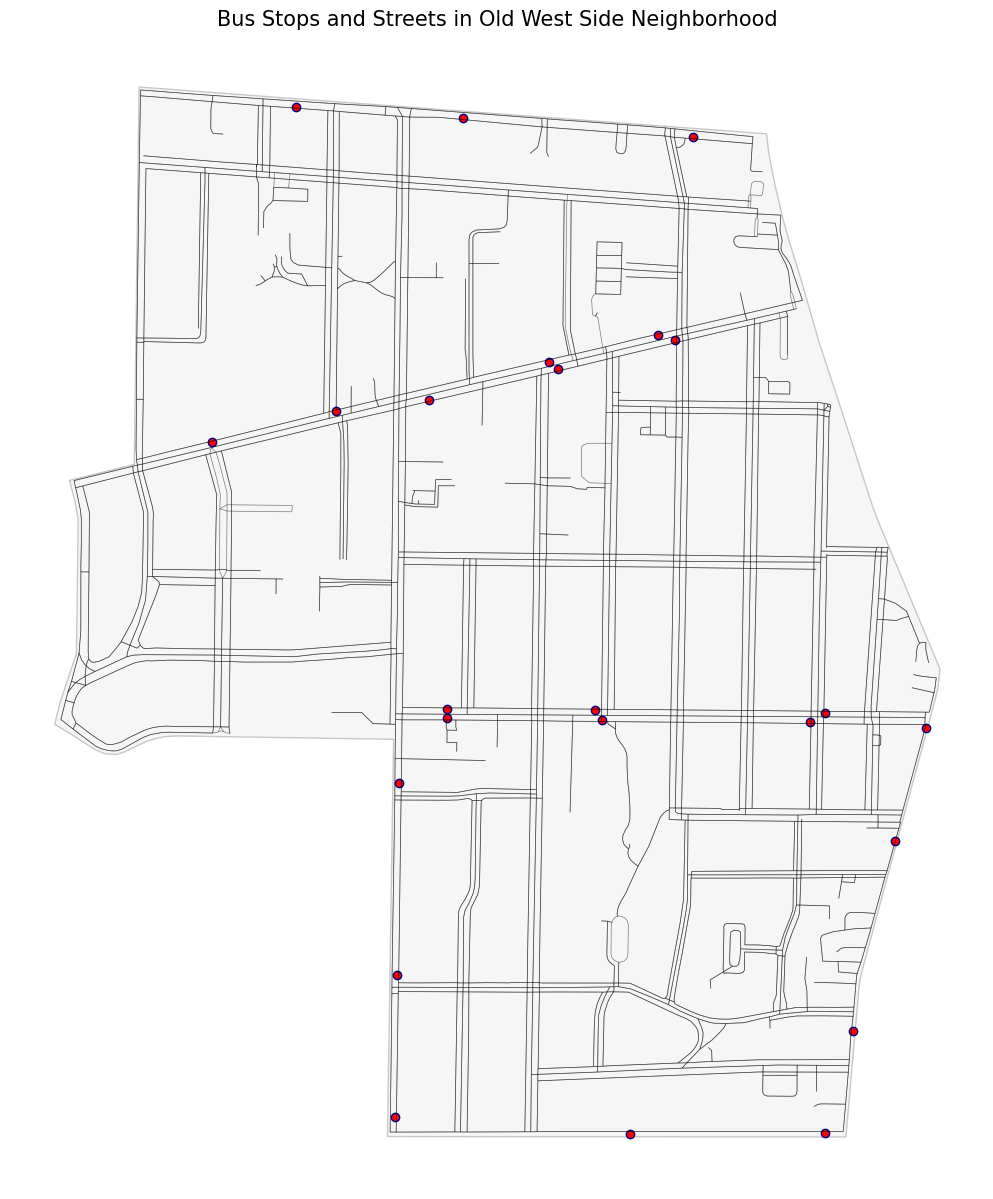

In [10]:
# Load the graph of the neighborhood
OWS_graph = ox.graph_from_place("Old West Side, Ann Arbor, Michigan, USA")

# Project the loaded graph
OWS_proj = ox.project_graph(OWS_graph)

# Extract the node and edges from the projection
OWS_node, OWS_edge = ox.graph_to_gdfs(OWS_proj, nodes = True, edges = True)

# Reproject old_west_side and bus_stops to the same CRS as the projected graph
old_west_side_proj = old_west_side.to_crs(OWS_edge.crs)
bus_stops_proj = bus_stops.to_crs(OWS_edge.crs)

fig, ax = plt.subplots(figsize=(15, 15))

old_west_side_proj.plot(ax = ax, color = "lightgray", edgecolor = "black", alpha = 0.2)
bus_stops_proj.plot(ax = ax, color = "red", edgecolor = "darkblue",  alpha = 1)
OWS_edge.plot(ax = ax, linewidth = 0.5, edgecolor = "black", alpha =  0.5)

ax.set_title("Bus Stops and Streets in Old West Side Neighborhood", fontsize=15)
ax.axis("off")
plt.show()

## Sanity Check
Before we start creating buffer zones, lets calculate the distance between two random bus stops to get an idea for if all the elements are in scale to lower the chances of errors.

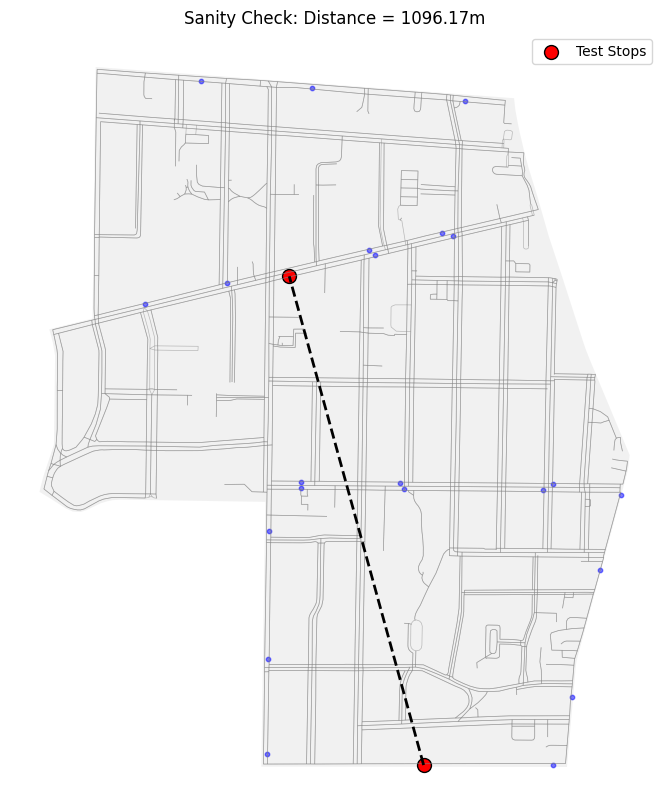

In [59]:
import random

i, j = random.randint(0, len(bus_stops_proj)), random.randint(0, len(bus_stops_proj))

# Extract the coordinates of the first and the second bus stop in the projected bus stop GeoDataFrame
stop_a = bus_stops_proj.iloc[i].geometry
stop_b = bus_stops_proj.iloc[j].geometry

# Calculate the distance between the two stops
dist = stop_a.distance(stop_b)

# Select the two stops to analyze
highlight_stops = bus_stops_proj.iloc[[i, j]]

# Re-plot the main map layers
fig, ax = plt.subplots(figsize=(10, 10))
old_west_side_proj.plot(ax=ax, color='lightgray', alpha=0.3)
OWS_edge.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.5)

# Plot all bus stops
bus_stops_proj.plot(ax=ax, color='blue', markersize=10, alpha=0.5)

# PLOT THE TWO TARGET STOPS (The "Sanity Check" Stops)
highlight_stops.plot(ax=ax, color='red', markersize=100, edgecolor='black', label='Test Stops')

# Draw a line between them to visualize the distance
x_coords = [highlight_stops.geometry.iloc[0].x, highlight_stops.geometry.iloc[1].x]
y_coords = [highlight_stops.geometry.iloc[0].y, highlight_stops.geometry.iloc[1].y]
ax.plot(x_coords, y_coords, color='black', linestyle='--', linewidth=2)

ax.set_title(f"Sanity Check: Distance = {dist:.2f}m")
ax.axis("off")
plt.legend()
plt.show()

### Adding buffer zones around the bus stops
A bus stop must be in reach of about 400 m - 800 m to be considered accessible on foot. So we provide a circular buffer zone around each bus stop of radius 400 m.

In [31]:
# Add a 400m buffer radius around the bus stops to indicate the feasible walking distance to the nearest bus stop
bus_stop_buffers = bus_stops_proj.buffer(400)

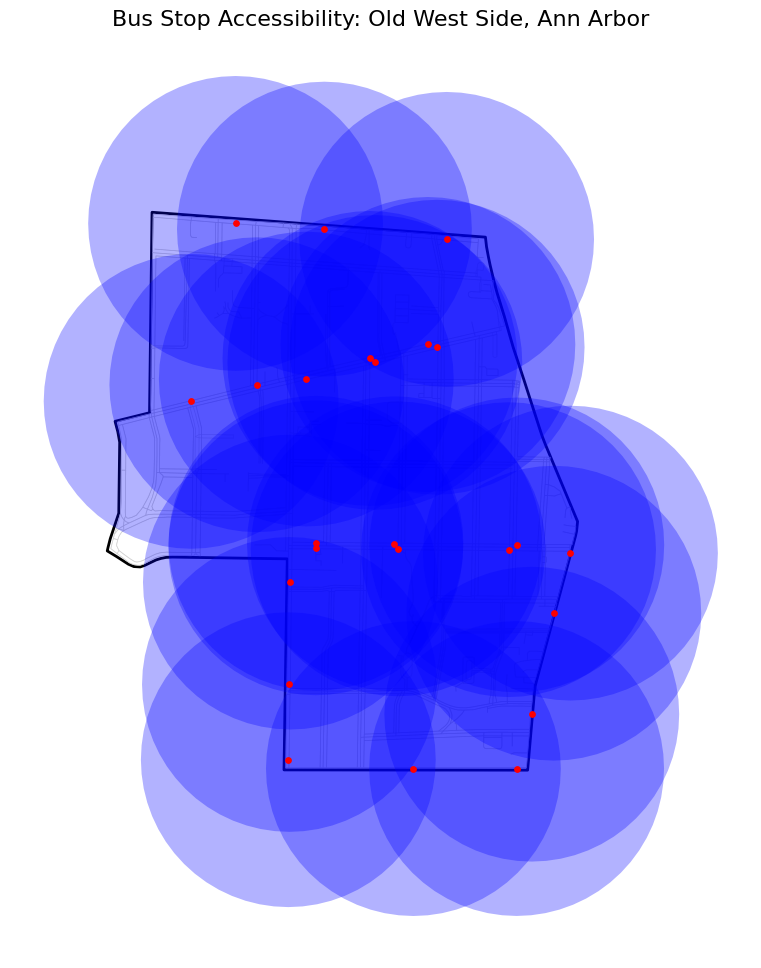

In [60]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the Neighborhood Boundary (The "Container")
old_west_side_proj.plot(ax=ax, color='none', edgecolor='black', linewidth=2, zorder=1)

# Plot the Road Network
OWS_edge.plot(ax=ax, color='#cccccc', linewidth=0.5, alpha=0.7, zorder=2)

# Plot the Buffers (The "Service Area")
bus_stop_buffers.plot(ax=ax, color='blue', alpha=0.3, zorder=3, label='Walkable Area')

# Plot the Bus Stop Points
bus_stops_proj.plot(ax=ax, color='red', markersize=15, zorder=4, label='Bus Stops')

# Formatting
ax.set_title("Bus Stop Accessibility: Old West Side, Ann Arbor", fontsize=16)
ax.set_axis_off()
plt.show()

As we can see from the above plot, the buffer zones intersect well with each other. We will now combine all the buffer zones to obtain a single buffer zone that encompasses all the bus stops.

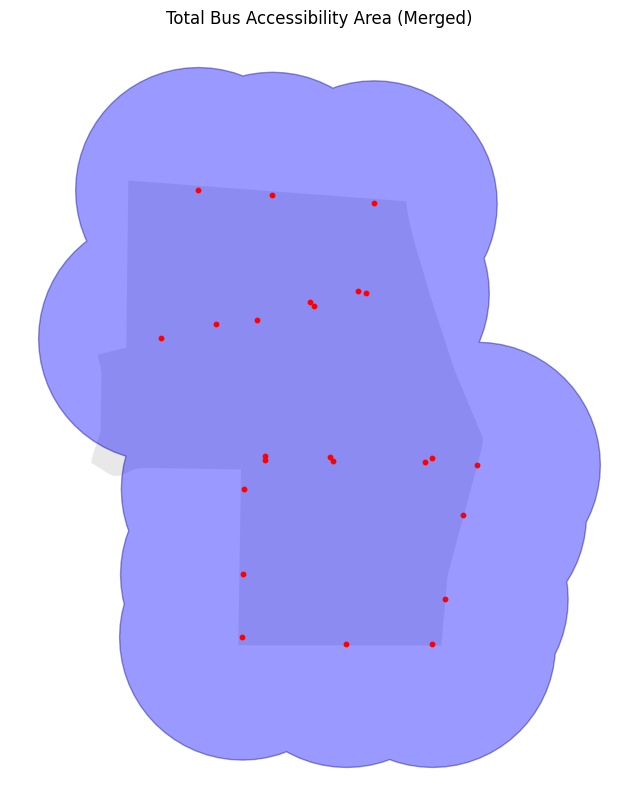

In [34]:
# Merge all the buffers into a single geometry
merged_buffers = bus_stop_buffers.union_all()


merged_buffers_gdf = gpd.GeoDataFrame(geometry = [merged_buffers], crs = bus_stop_buffers.crs)

# visualize the merged buffer
fig, ax = plt.subplots(figsize = (10, 10))

old_west_side_proj.plot(ax=ax, color='lightgray', alpha=0.5)
merged_buffers_gdf.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue')
bus_stops_proj.plot(ax=ax, color='red', markersize=10)

ax.set_title("Total Bus Accessibility Area (Merged)")
ax.axis("off")
plt.show()

We will now subtract the combined buffer zone from the boundary of Old West Side to obtain areas where the bus stops are not easily obtainable i.e. blind spots.

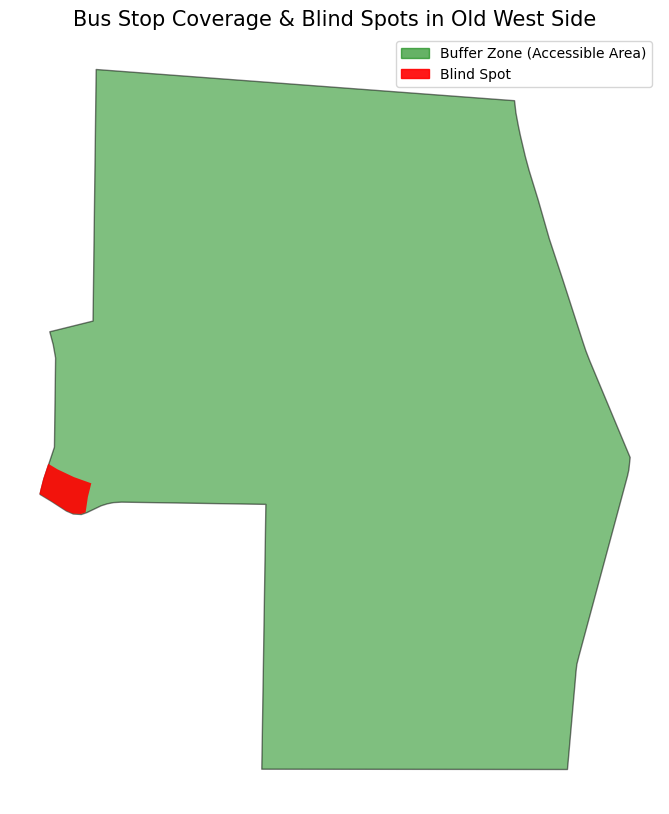

In [30]:
import matplotlib.patches as mpatches

# Subtract the merged buffer from the neighborhood boundary
blind_spots = old_west_side_proj.geometry.difference(merged_buffers_gdf.geometry)

fig, ax = plt.subplots(figsize = (10, 10))

# Plot the entire neighborhood as a background
old_west_side_proj.plot(ax=ax, color='green', edgecolor='black', alpha=0.5)

# Plot the blind spots in red
blind_spots.plot(ax=ax, color='red', alpha=0.9)

# Create custom legend patches
green_patch = mpatches.Patch(color='green', alpha=0.6, label='Buffer Zone (Accessible Area)')
red_patch = mpatches.Patch(color='red', alpha=0.9, label='Blind Spot')

ax.set_title("Bus Stop Coverage & Blind Spots in Old West Side", fontsize=15)
ax.axis("off")
plt.legend(handles=[green_patch, red_patch], loc='upper right')
plt.show()

### What the above map implies?
As we can see, Old West Side has a ***good accessibility*** for bus stops with only a small area (red area) as a blind spot.
This means that residents of Old West Side have access to buses within a walking distance of 400 meters or less.